In [5]:
from MLEvaluator import MLEvaluator

In [6]:
evaluator = MLEvaluator.load("evaluator.pkl")

Evaluator chargé depuis 'evaluator.pkl'
   Modèles disponibles : ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']


In [7]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# CLASSE SHAP
# ============================================================
class SHAPEvaluator:

    def __init__(self, ml_evaluator):
        """
        Initialise le SHAPEvaluator à partir d'un MLEvaluator déjà entraîné.

        Args:
            ml_evaluator : instance de MLEvaluator avec modèles déjà entraînés
        """
        # On récupère tout ce dont on a besoin depuis MLEvaluator
        self.trained_models = ml_evaluator.trained_models  # modèles entraînés
        self.X_train = ml_evaluator.X_train                # features train
        self.X_test = ml_evaluator.X_test                  # features test
        self.y_train = ml_evaluator.y_train                # cible train
        self.y_test = ml_evaluator.y_test                  # cible test
        self.feature_names = ml_evaluator.feature_names    # noms des colonnes
        self.all_predictions = ml_evaluator.all_predictions

        # Tiroirs propres à SHAP
        self.shap_explainers = {}    # un explainer par modèle
        self.shap_values = {}        # valeurs SHAP calculées
        self.selected_samples = {}   # échantillons sélectionnés par classe
        self.shap_metrics = {}       # stabilité + fidélité

        # Mapping classes encodées → noms lisibles
        self.classes = ["E-P+", "E+P+", "E+P-", "E-P-"]
        self.class_mapping = {}
        # Modèles sélectionnés pour SHAP
        self.selected_models = ["Random_Forest", "XGBoost", "Decision_Tree"]
        unique_labels = sorted(self.y_test.unique())
        for i, class_name in enumerate(self.classes):
            if i < len(unique_labels):
                self.class_mapping[unique_labels[i]] = class_name

        print("SHAPEvaluator initialisé")
        print(f"   Modèles disponibles : {list(self.trained_models.keys())}")
        print(f"   Features            : {len(self.feature_names)}")
        print(f"   Class mapping       : {self.class_mapping}")

    def select_samples_for_explanation(self):
        print("\n SÉLECTION DES ÉCHANTILLONS POUR SHAP")
        print("=" * 60)

        # On utilise les prédictions déjà calculées par MLEvaluator
        # plus besoin de recalculer !
        selected_samples = {}

        for encoded_class, class_name in self.class_mapping.items():
            print(f"\nClasse : {class_name} (encodée comme {encoded_class})")

            class_indices = self.y_test[
                self.y_test == encoded_class
            ].index.tolist()
            print(f" Total échantillons dans la classe : {len(class_indices)}")

            correctly_predicted = []

            for idx in class_indices:
                pos = list(self.y_test.index).index(idx)

                # On utilise self.all_predictions au lieu de recalculer
                all_correct = all(
                    preds[pos] == encoded_class
                    for preds in self.all_predictions.values()
                )

                if all_correct:
                    correctly_predicted.append(pos)

            print(f"Bien prédits par tous les modèles : {len(correctly_predicted)}")

            if len(correctly_predicted) >= 4:
                np.random.seed(42)
                selected = np.random.choice(
                    correctly_predicted, 4, replace=False
                ).tolist()
                print(f" 4 échantillons sélectionnés : {selected}")
            elif len(correctly_predicted) > 0:
                selected = correctly_predicted
                print(f"   {len(selected)} échantillons sélectionnés : {selected}")
            else:
                selected = []
                print(f" Aucun échantillon bien prédit par tous les modèles")

            selected_samples[class_name] = selected

        self.selected_samples = selected_samples

        total = sum(len(v) for v in selected_samples.values())
        print(f"\n RÉSUMÉ :")
        print(f"   Total échantillons sélectionnés : {total}")
        for class_name, indices in selected_samples.items():
            print(f"   {class_name} : {len(indices)} échantillons")

        return selected_samples

    def create_shap_explainer(self, model, model_name):
        """
        Crée l'explainer SHAP adapté au type de modèle.

        Chaque famille de modèles a son propre explainer optimisé :
        - TreeExplainer    → modèles basés sur des arbres (rapide)
        - LinearExplainer  → modèles linéaires (rapide)
        - KernelExplainer  → tous les autres (lent mais universel)

        Args:
            model      : modèle entraîné
            model_name : nom du modèle

        Returns:
            explainer SHAP correspondant
        """
        print(f"   Création de l'explainer pour {model_name}...")

        try:
            # ---- Modèles basés sur des arbres → TreeExplainer ----
            if model_name in [
                "Random_Forest",
                "Extra_Trees",
                "Gradient_Boosting",
                "Decision_Tree",
                "XGBoost"        # ← ajout par rapport à ta camarade
            ]:
                explainer = shap.TreeExplainer(model)
                print(f"TreeExplainer créé pour {model_name}")

            # ---- Régression logistique → LinearExplainer ----
            elif model_name == "Logistic_Regression":
                explainer = shap.LinearExplainer(model, self.X_train)
                print(f" LinearExplainer créé pour {model_name}")

            # ---- Tous les autres → KernelExplainer (lent️) ----
            elif model_name in ["SVM", "KNN", "Naive_Bayes", "Bagging", "MLP"]:
                # On prend un échantillon du train comme référence
                # min(50, ...) → maximum 50 lignes pour limiter le temps de calcul
                background = shap.sample(
                    self.X_train, min(50, len(self.X_train))
                )
                explainer = shap.KernelExplainer(model.predict_proba, background)
                print(f"KernelExplainer créé pour {model_name} (peut être lent)")

            else:
                # Fallback — modèle inconnu → KernelExplainer par défaut
                print(f" Modèle inconnu, KernelExplainer utilisé par défaut")
                background = shap.sample(
                    self.X_train, min(50, len(self.X_train))
                )
                explainer = shap.KernelExplainer(model.predict_proba, background)

            return explainer

        except Exception as e:
            print(f" Erreur création explainer pour {model_name} : {e}")
            return None

    def generate_shap_explanations(self):
        """
        Calcule les valeurs SHAP pour chaque modèle
        sur les échantillons sélectionnés.

        Pour chaque modèle :
        1. Crée l'explainer adapté
        2. Récupère les échantillons sélectionnés
        3. Calcule les valeurs SHAP
        4. Sauvegarde dans self.shap_values
        """
        print("\n CALCUL DES VALEURS SHAP")
        print("=" * 60)

        # Collecter tous les indices sélectionnés
        all_selected_indices = []
        for indices in self.selected_samples.values():
            all_selected_indices.extend(indices)

        if not all_selected_indices:
            print("Aucun échantillon sélectionné — lance d'abord select_samples_for_explanation()")
            return

        # Extraire les données des échantillons sélectionnés
        X_selected = self.X_test.iloc[all_selected_indices]
        print(f"   Échantillons à expliquer : {len(X_selected)}")

        # Calculer les valeurs SHAP pour chaque modèle
        for model_name, model in self.trained_models.items():
            if model_name not in self.selected_models:
                print(f"   ⏭️ {model_name} ignoré")
                continue

            print(f"\n   Modèle : {model_name}")
            try:
                # Créer l'explainer
                explainer = self.create_shap_explainer(model, model_name)

                if explainer is None:
                    print(f"Explainer non créé — {model_name} ignoré")
                    continue

                # Sauvegarder l'explainer
                self.shap_explainers[model_name] = explainer

                # Calculer les valeurs SHAP
                shap_values = explainer.shap_values(X_selected)

                # Normaliser le format pour la visualisation
                # TreeExplainer renvoie une liste [classe0, classe1, ...]
                # KernelExplainer renvoie un array 2D ou 3D
                if isinstance(shap_values, list):
                    # Multiclasse → liste de matrices
                    # On garde la liste complète pour les métriques
                    # On prend la classe 0 pour les visualisations
                    shap_values_plot = shap_values[0]
                else:
                    if shap_values.ndim == 3:
                        # Shape (n_samples, n_features, n_classes)
                        shap_values_plot = shap_values[:, :, 0]
                    else:
                        shap_values_plot = shap_values

                # Sauvegarder
                self.shap_values[model_name] = {
                    "values"           : shap_values,       # valeurs complètes
                    "values_plot"      : shap_values_plot,  # valeurs pour visualisation
                    "data"             : X_selected,        # données des échantillons
                    "selected_indices" : all_selected_indices  # indices originaux
                }

                print(f"Valeurs SHAP calculées — shape : {np.array(shap_values_plot).shape}")

            except Exception as e:
                print(f" Erreur pour {model_name} : {e}")
                continue

        print(f"\nValeurs SHAP calculées pour {len(self.shap_values)} modèles")

    def plot_shap_explanations(self, model_name):
        """
        Génère les graphiques SHAP pour un modèle donné :
        1. Summary plot   → vue globale des features importantes
        2. Waterfall plot → explication détaillée par échantillon
        3. Bar plot       → importance moyenne des features

        Args:
            model_name : nom du modèle à visualiser
        """
        if model_name not in self.shap_values:
            print(f"Pas de valeurs SHAP pour {model_name}")
            return

        print(f"\n  GRAPHIQUES SHAP — {model_name}")
        print("=" * 60)

        shap_data      = self.shap_values[model_name]
        shap_vals      = shap_data["values"]
        shap_vals_plot = shap_data["values_plot"]
        X_selected     = shap_data["data"]
        selected_indices = shap_data["selected_indices"]
        model          = self.trained_models[model_name]

        # --------------------------------------------------------
        # GRAPHIQUE 1 — Summary Plot
        # Vue globale : quelles features influencent le plus
        # les prédictions sur tous les échantillons
        # --------------------------------------------------------
        print("\n Summary Plot...")
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_vals_plot,
                X_selected,
                feature_names=self.feature_names,
                show=False,
                max_display=10      # top 10 features
            )
            plt.title(f"SHAP Summary Plot — {model_name}", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f" Erreur summary plot : {e}")

        # --------------------------------------------------------
        # GRAPHIQUE 2 — Bar Plot
        # Importance moyenne absolue de chaque feature
        # --------------------------------------------------------
        print("\n Bar Plot...")
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_vals_plot,
                X_selected,
                feature_names=self.feature_names,
                plot_type="bar",
                show=False,
                max_display=15
            )
            plt.title(f"SHAP Feature Importance — {model_name}", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f" Erreur bar plot : {e}")

        # --------------------------------------------------------
        # GRAPHIQUE 3 — Waterfall Plot par échantillon
        # Explication détaillée pour chaque échantillon sélectionné
        # Montre comment chaque feature pousse la prédiction
        # vers le haut ou vers le bas
        # --------------------------------------------------------
        print("\n Waterfall Plots (un par échantillon)...")

        # Récupérer les vraies classes et prédictions
        y_true_selected = [self.y_test.iloc[idx] for idx in selected_indices]
        y_pred_selected = model.predict(X_selected)

        # Récupérer la valeur de base (expected value)
        if hasattr(self.shap_explainers[model_name], "expected_value"):
            expected_value = self.shap_explainers[model_name].expected_value
            # Si multiclasse → liste de valeurs de base, une par classe
            if isinstance(expected_value, (list, np.ndarray)):
                expected_value = expected_value[0]
        else:
            expected_value = 0

        # Un waterfall par échantillon
        for i in range(len(X_selected)):
            try:
                # Noms lisibles des classes
                true_class = self.class_mapping.get(
                    int(y_true_selected[i]), f"Classe {y_true_selected[i]}"
                )
                pred_class = self.class_mapping.get(
                    int(y_pred_selected[i]), f"Classe {y_pred_selected[i]}"
                )
                correct = "OK" if true_class == pred_class else "KO"

                plt.figure(figsize=(14, 8))

                # Créer l'objet Explanation pour le waterfall
                explanation = shap.Explanation(
                    values=shap_vals_plot[i],
                    base_values=expected_value,
                    data=X_selected.iloc[i].values,
                    feature_names=self.feature_names
                )

                try:
                    shap.waterfall_plot(explanation, max_display=15, show=False)
                except:
                    # Fallback si waterfall ne marche pas
                    shap.force_plot(
                        expected_value,
                        shap_vals_plot[i],
                        X_selected.iloc[i],
                        feature_names=self.feature_names,
                        matplotlib=True,
                        show=False
                    )

                plt.suptitle(
                    f"{model_name} — Échantillon {i+1}/{len(X_selected)} {correct}\n"
                    f"Vraie classe : {true_class} | Prédiction : {pred_class}",
                    fontsize=12,
                    y=1.02
                )
                plt.tight_layout()
                plt.show()

                print(f"   Échantillon {i+1} : Vraie={true_class} | Prédit={pred_class} {correct}")

            except Exception as e:
                print(f"   Erreur waterfall échantillon {i+1} : {e}")
                continue

    def plot_shap_comparison(self):
        """
        Compare les valeurs SHAP entre tous les modèles :
        1. Heatmap        → importance de chaque feature par modèle
        2. Bar chart      → top 10 features en moyenne sur tous les modèles

        Permet de répondre à :
        "Est-ce que tous les modèles s'accordent sur les mêmes features ?"
        """
        print("\nCOMPARAISON SHAP ENTRE MODÈLES")
        print("=" * 60)

        if not self.shap_values:
            print("Aucune valeur SHAP disponible")
            return

        # --------------------------------------------------------
        # Calculer l'importance moyenne absolue par modèle
        # --------------------------------------------------------
        feature_importance_dict = {}

        for model_name, shap_data in self.shap_values.items():
            shap_vals = shap_data["values"]

            try:
                # Gérer les différents formats de valeurs SHAP
                if isinstance(shap_vals, list):
                    # Multiclasse → liste de matrices
                    # On moyenne l'importance sur toutes les classes
                    mean_abs_shap = np.mean(
                        [np.mean(np.abs(v), axis=0) for v in shap_vals],
                        axis=0
                    )
                elif shap_vals.ndim == 3:
                    # Shape (n_samples, n_features, n_classes)
                    mean_abs_shap = np.mean(np.abs(shap_vals), axis=(0, 2))
                else:
                    # Shape (n_samples, n_features)
                    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)

                # Vérifier que la taille correspond au nombre de features
                if len(mean_abs_shap) == len(self.feature_names):
                    feature_importance_dict[model_name] = mean_abs_shap
                else:
                    print(f" Taille incorrecte pour {model_name} — ignoré")

            except Exception as e:
                print(f" Erreur pour {model_name} : {e}")
                continue

        if not feature_importance_dict:
            print("Aucune valeur valide pour la comparaison")
            return

        # Créer un DataFrame de comparaison
        # Lignes = features, Colonnes = modèles
        comparison_df = pd.DataFrame(
            feature_importance_dict,
            index=self.feature_names
        )

        # --------------------------------------------------------
        # GRAPHIQUE 1 — Heatmap
        # Montre l'importance de chaque feature pour chaque modèle
        # --------------------------------------------------------
        print("\n  Heatmap de comparaison...")
        try:
            plt.figure(figsize=(14, 10))
            sns.heatmap(
                comparison_df,
                annot=True,
                cmap="Blues",
                fmt=".3f",
                linewidths=0.5
            )
            plt.title(
                "Comparaison SHAP — Importance des features par modèle",
                fontsize=14
            )
            plt.xlabel("Modèles")
            plt.ylabel("Features")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  Erreur heatmap : {e}")

        # --------------------------------------------------------
        # GRAPHIQUE 2 — Bar Chart Top 10 features
        # Importance moyenne sur tous les modèles
        # --------------------------------------------------------
        print("\n Top 10 features (moyenne tous modèles)...")
        try:
            # Calculer la moyenne par feature sur tous les modèles
            top_features = comparison_df.mean(axis=1).nlargest(10)

            plt.figure(figsize=(14, 6))
            comparison_df.loc[top_features.index].plot(
                kind="bar",
                width=0.8,
                figsize=(14, 6)
            )
            plt.title(
                "Top 10 Features — Comparaison SHAP entre modèles",
                fontsize=14
            )
            plt.xlabel("Features")
            plt.ylabel("Valeur SHAP absolue moyenne")
            plt.legend(
                title="Modèles",
                bbox_to_anchor=(1.05, 1),
                loc="upper left"
            )
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  Erreur bar chart : {e}")


        # Afficher un résumé textuel
        print("\nRÉSUMÉ — Top 5 features par modèle :")
        for model_name in comparison_df.columns:
            top5 = comparison_df[model_name].nlargest(5)
            print(f"\n   {model_name} :")
            for feat, val in top5.items():
                print(f"      {feat:40} : {val:.4f}")

    def calculate_stability(self, n_perturbations=10):
        """
        Calcule la stabilité des explications SHAP.

        Principe :
        1. Calculer les valeurs SHAP pour un échantillon
        2. Ajouter un tout petit bruit sur les features
        3. Recalculer les valeurs SHAP
        4. Mesurer la corrélation entre les deux → proche de 1 = stable

        Args:
            n_perturbations : nombre de fois qu'on perturbe chaque échantillon
        """
        print("\n CALCUL DE LA STABILITÉ")
        print("=" * 60)

        stability_results = {}

        for model_name, model in self.trained_models.items():
            print(f"\n   Modèle : {model_name}")

            # Créer l'explainer
            explainer = self.create_shap_explainer(model, model_name)
            if explainer is None:
                continue

            model_stabilities = {}

            for class_name, sample_indices in self.selected_samples.items():
                if not sample_indices:
                    continue

                class_stabilities = []

                for sample_idx in sample_indices:
                    sample = self.X_test.iloc[[sample_idx]]

                    try:
                        # Valeurs SHAP originales
                        original_shap = explainer.shap_values(sample)

                        # Aplatir en vecteur 1D
                        if isinstance(original_shap, list):
                            # Multiclasse → concaténer toutes les classes
                            original_values = np.concatenate(
                                [arr.flatten() for arr in original_shap]
                            )
                        else:
                            original_values = original_shap.flatten()

                        correlations = []

                        # Écart-type de chaque feature (pour calibrer le bruit)
                        feature_std = sample.std(axis=0).fillna(1.0)

                        for _ in range(n_perturbations):
                            # Ajouter un très petit bruit (0.1% de l'écart-type)
                            noise = np.random.normal(
                                0,
                                feature_std * 0.001,
                                sample.shape
                            )
                            perturbed_sample = sample + noise

                            # Valeurs SHAP perturbées
                            perturbed_shap = explainer.shap_values(perturbed_sample)

                            if isinstance(perturbed_shap, list):
                                perturbed_values = np.concatenate(
                                    [arr.flatten() for arr in perturbed_shap]
                                )
                            else:
                                perturbed_values = perturbed_shap.flatten()

                            # Corrélation entre original et perturbé
                            if (
                                len(original_values) == len(perturbed_values)
                                and np.var(original_values) > 1e-10
                                and np.var(perturbed_values) > 1e-10
                            ):
                                corr = np.corrcoef(
                                    original_values, perturbed_values
                                )[0, 1]
                                if not np.isnan(corr):
                                    correlations.append(max(0, corr))

                        if correlations:
                            class_stabilities.append(np.mean(correlations))

                    except Exception as e:
                        print(f"      Erreur échantillon {sample_idx} : {e}")
                        continue

                if class_stabilities:
                    model_stabilities[class_name] = {
                        "mean": np.mean(class_stabilities),
                        "std" : np.std(class_stabilities),
                        "individual": class_stabilities
                    }
                    print(
                        f"      {class_name} : "
                        f"{np.mean(class_stabilities):.4f} ± "
                        f"{np.std(class_stabilities):.4f}"
                    )

            stability_results[model_name] = model_stabilities

        self.shap_metrics["stability"] = stability_results
        print("\n Stabilité calculée")
        return stability_results


    def calculate_fidelity(self):
        """
        Calcule la fidélité des explications SHAP.

        Principe :
        base_value + somme(shap_values) ≈ prédiction du modèle

        Fidélité = 1 - |reconstruction - prédiction réelle|
        → proche de 1 = très fidèle
        → proche de 0 = pas fidèle
        """
        print("\n CALCUL DE LA FIDÉLITÉ")
        print("=" * 60)

        fidelity_results = {}

        for model_name, model in self.trained_models.items():
            print(f"\n   Modèle : {model_name}")

            explainer = self.create_shap_explainer(model, model_name)
            if explainer is None:
                continue

            model_fidelities = {}

            for class_name, sample_indices in self.selected_samples.items():
                if not sample_indices:
                    continue

                class_fidelities = []

                for sample_idx in sample_indices:
                    sample = self.X_test.iloc[[sample_idx]]

                    try:
                        # Prédiction réelle du modèle
                        model_proba = model.predict_proba(sample)[0]
                        predicted_class = np.argmax(model_proba)
                        model_output = model_proba[predicted_class]

                        # Valeurs SHAP
                        shap_values = explainer.shap_values(sample)

                        # Valeur de base
                        if hasattr(explainer, "expected_value"):
                            expected_value = explainer.expected_value
                            if isinstance(expected_value, (list, np.ndarray)):
                                base_value = (
                                    expected_value[predicted_class]
                                    if len(expected_value) > predicted_class
                                    else expected_value[0]
                                )
                            else:
                                base_value = expected_value
                        else:
                            base_value = 0

                        # Somme des valeurs SHAP pour la classe prédite
                        if isinstance(shap_values, list):
                            shap_sum = np.sum(shap_values[predicted_class])
                        elif shap_values.ndim == 3:
                            shap_sum = np.sum(
                                shap_values[0, :, predicted_class]
                            )
                        else:
                            shap_sum = np.sum(shap_values)

                        # Reconstruction : base + somme SHAP ≈ prédiction
                        reconstructed = base_value + shap_sum

                        # Fidélité = 1 - erreur absolue
                        fidelity = 1.0 - min(
                            1.0, abs(reconstructed - model_output)
                        )
                        fidelity = max(0.0, fidelity)

                        class_fidelities.append(fidelity)

                    except Exception as e:
                        print(f"      Erreur échantillon {sample_idx} : {e}")
                        continue

                if class_fidelities:
                    model_fidelities[class_name] = {
                        "mean": np.mean(class_fidelities),
                        "std" : np.std(class_fidelities),
                        "individual": class_fidelities
                    }
                    print(
                        f"      {class_name} : "
                        f"{np.mean(class_fidelities):.4f} ± "
                        f"{np.std(class_fidelities):.4f}"
                    )

            fidelity_results[model_name] = model_fidelities

        self.shap_metrics["fidelity"] = fidelity_results
        print("\nFidélité calculée")
        return fidelity_results

    def print_summary(self):
        """
        Affiche un résumé complet des métriques SHAP :
        - Stabilité par classe et par modèle
        - Fidélité par classe et par modèle
        - Évaluation qualitative (bon/moyen/mauvais)
        """
        print("\n" + "=" * 70)
        print("📊 RÉSUMÉ DES MÉTRIQUES SHAP")
        print("=" * 70)

        if not self.shap_metrics:
            print(" Aucune métrique calculée")
            return

        stability = self.shap_metrics.get("stability", {})
        fidelity  = self.shap_metrics.get("fidelity", {})

        for model_name in self.trained_models.keys():
            print(f"\n🤖 {model_name.upper().replace('_', ' ')}")
            print("-" * 60)

            # ---- Stabilité ----
            print(" STABILITÉ (max = 1.0, plus c'est élevé mieux c'est) :")
            stability_scores = []

            if model_name in stability:
                for class_name, data in stability[model_name].items():
                    print(
                        f"   {class_name:8} : "
                        f"{data['mean']:.4f} ± {data['std']:.4f}"
                    )
                    stability_scores.append(data["mean"])

                overall_stability = np.mean(stability_scores)
                print(f"   Overall  : {overall_stability:.4f}")
            else:
                print("    Pas de données de stabilité")
                overall_stability = 0

            # ---- Fidélité ----
            print("\n🎯 FIDÉLITÉ (max = 1.0, plus c'est élevé mieux c'est) :")
            fidelity_scores = []

            if model_name in fidelity:
                for class_name, data in fidelity[model_name].items():
                    print(
                        f"   {class_name:8} : "
                        f"{data['mean']:.4f} ± {data['std']:.4f}"
                    )
                    fidelity_scores.append(data["mean"])

                overall_fidelity = np.mean(fidelity_scores)
                print(f"   Overall  : {overall_fidelity:.4f}")
            else:
                print("    Pas de données de fidélité")
                overall_fidelity = 0

            # ---- Évaluation qualitative ----
            print("\n ÉVALUATION :")

            # Stabilité
            if overall_stability > 0.8:
                print("   Stabilité élevée — explications reproductibles")
            elif overall_stability > 0.6:
                print("    Stabilité modérée — explications partiellement reproductibles")
            else:
                print("   Stabilité faible — explications peu fiables")

            # Fidélité
            if overall_fidelity > 0.8:
                print("   Fidélité élevée — explications fidèles au modèle")
            elif overall_fidelity > 0.6:
                print("    Fidélité modérée — explications approximatives")
            else:
                print("   Fidélité faible — explications ne reflètent pas le modèle")


    # --------------------------------------------------------
    # MÉTHODE PRINCIPALE
    # --------------------------------------------------------
    def run(self):
        """
        Lance tout le pipeline SHAP dans l'ordre :

        1. Sélectionner les échantillons par classe
        2. Calculer les valeurs SHAP pour tous les modèles
        3. Générer les graphiques par modèle
        4. Générer la comparaison entre modèles
        5. Calculer la stabilité
        6. Calculer la fidélité
        7. Afficher le résumé
        """
        print(" LANCEMENT DU PIPELINE SHAP")
        print("=" * 70)

        # Étape 1 — Sélection des échantillons
        self.select_samples_for_explanation()

        # Étape 2 — Calcul des valeurs SHAP
        self.generate_shap_explanations()

        # Étape 3 — Graphiques par modèle
        print("\n GÉNÉRATION DES GRAPHIQUES PAR MODÈLE")
        print("=" * 70)
        for model_name in self.shap_values.keys():
            self.plot_shap_explanations(model_name)

        # Étape 4 — Comparaison entre modèles
        if len(self.shap_values) > 1:
            self.plot_shap_comparison()

        # Étape 5 — Stabilité
        self.calculate_stability()

        # Étape 6 — Fidélité
        self.calculate_fidelity()

        # Étape 7 — Résumé
        self.print_summary()

        print("\n PIPELINE SHAP TERMINÉ !")


SHAPEvaluator initialisé
   Modèles disponibles : ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']
   Features            : 184
   Class mapping       : {np.int64(0): 'E-P+', np.int64(1): 'E+P+', np.int64(2): 'E+P-', np.int64(3): 'E-P-'}
 LANCEMENT DU PIPELINE SHAP

 SÉLECTION DES ÉCHANTILLONS POUR SHAP

Classe : E-P+ (encodée comme 0)
 Total échantillons dans la classe : 7
Bien prédits par tous les modèles : 1
   1 échantillons sélectionnés : [21]

Classe : E+P+ (encodée comme 1)
 Total échantillons dans la classe : 4
Bien prédits par tous les modèles : 0
 Aucun échantillon bien prédit par tous les modèles

Classe : E+P- (encodée comme 2)
 Total échantillons dans la classe : 9
Bien prédits par tous les modèles : 6
 4 échantillons sélectionnés : [0, 1, 15, 3]

Classe : E-P- (encodée comme 3)
 Total échantillons dans la classe : 6
Bien prédits par tous les modèles : 1
   1 échantillons

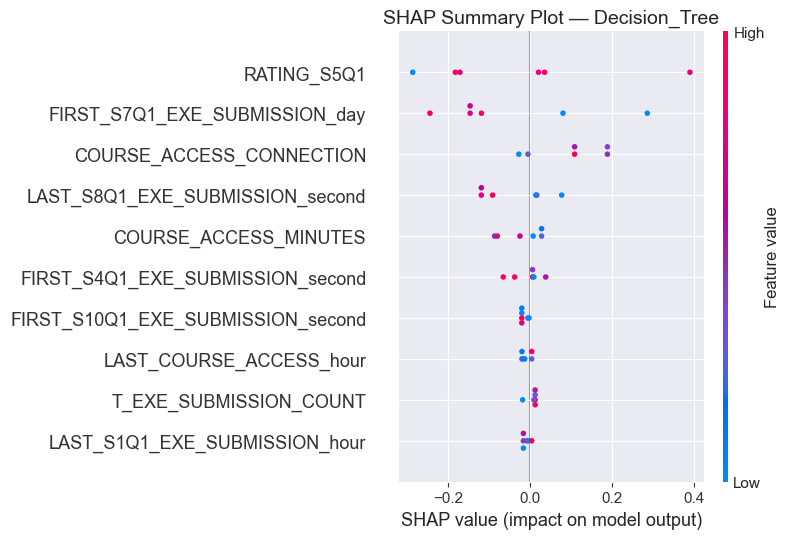


 Bar Plot...


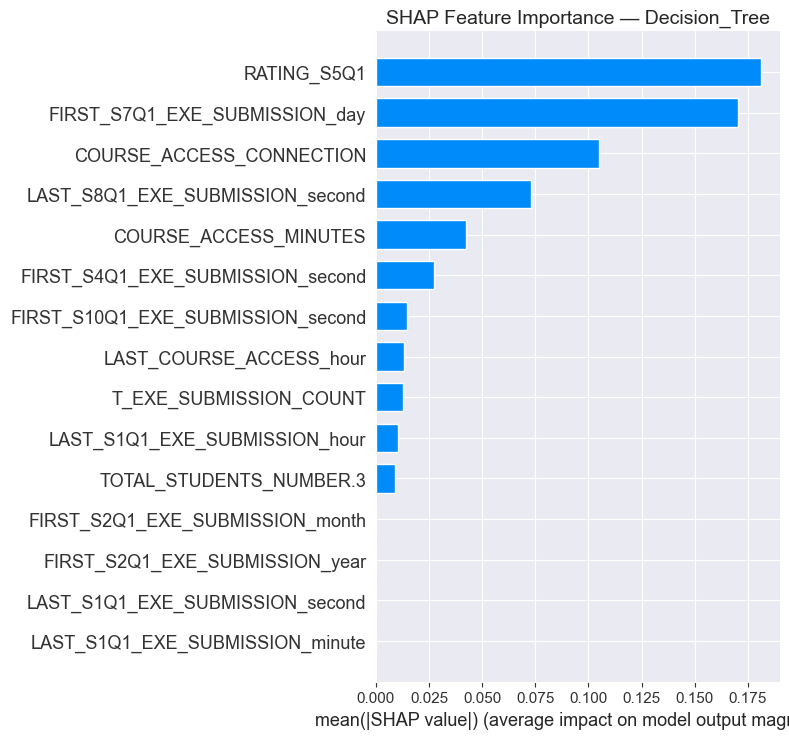


 Waterfall Plots (un par échantillon)...


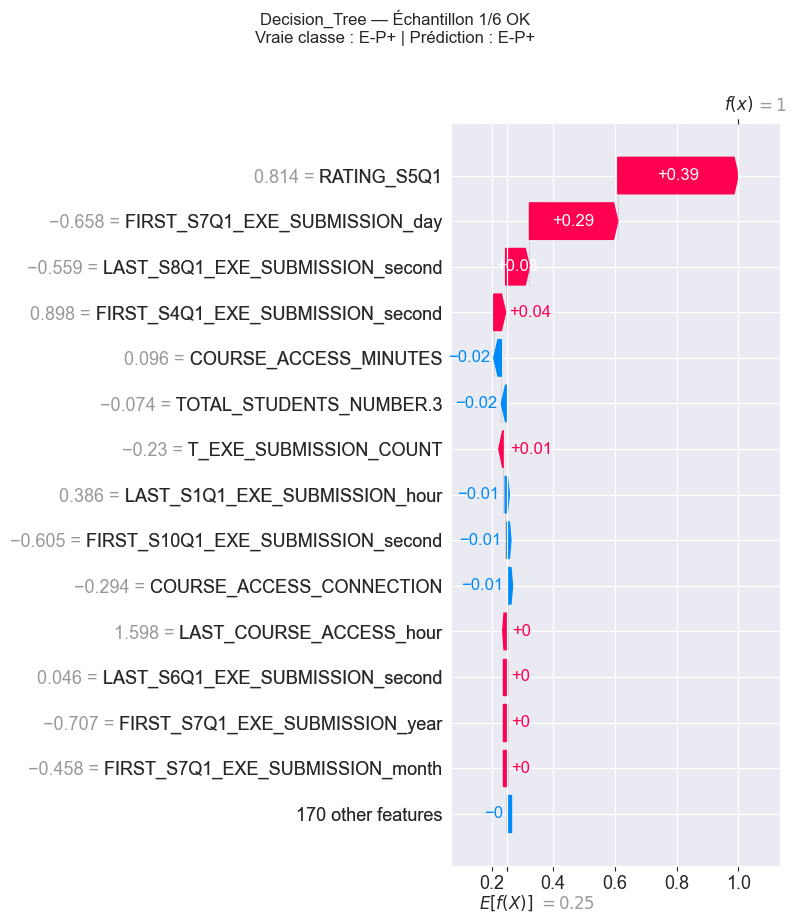

   Échantillon 1 : Vraie=E-P+ | Prédit=E-P+ OK


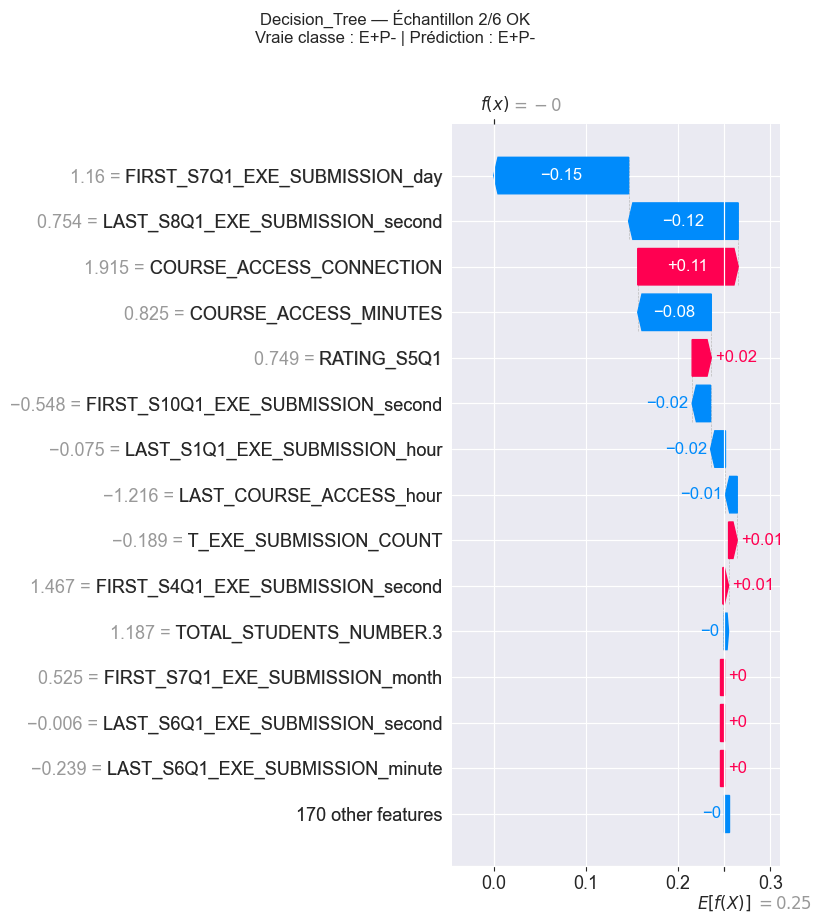

   Échantillon 2 : Vraie=E+P- | Prédit=E+P- OK


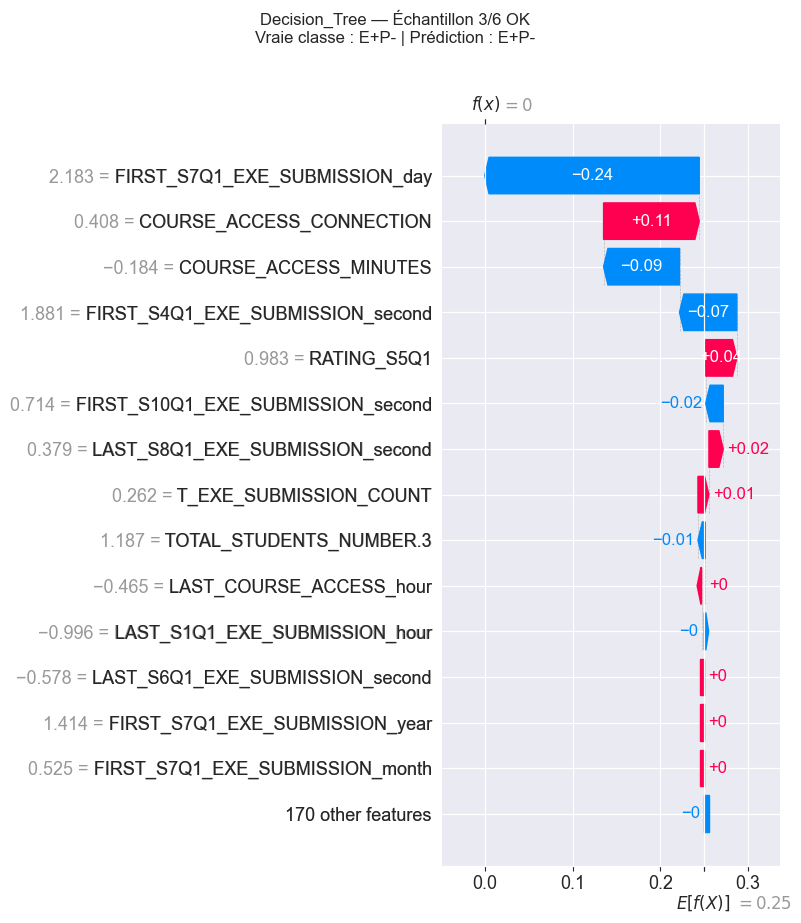

   Échantillon 3 : Vraie=E+P- | Prédit=E+P- OK


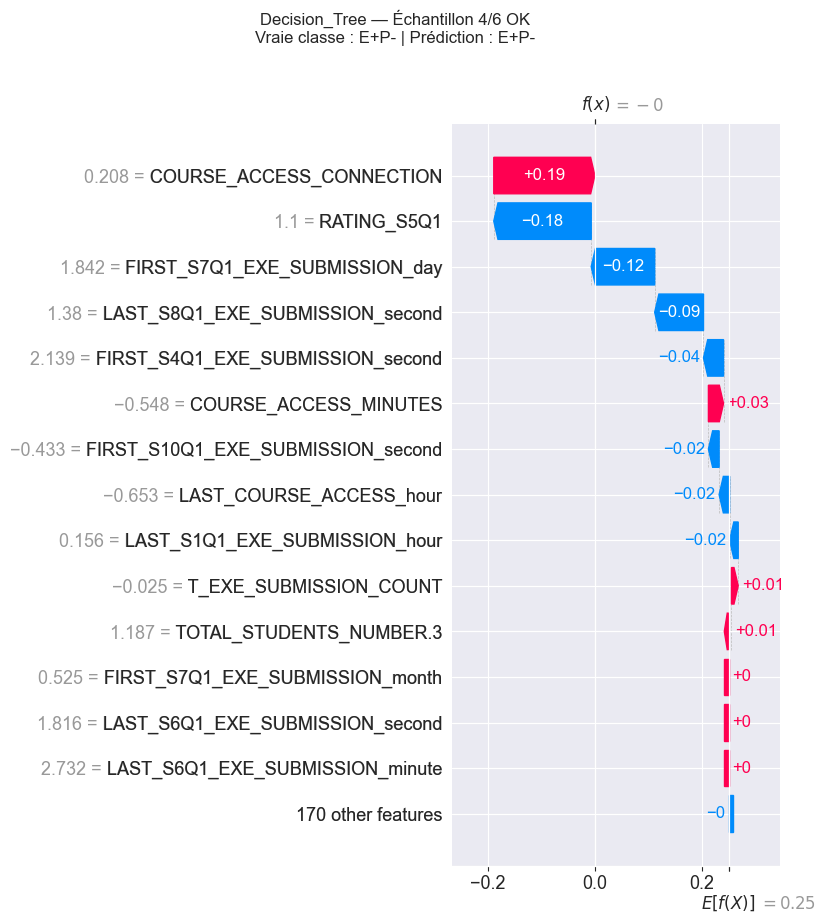

   Échantillon 4 : Vraie=E+P- | Prédit=E+P- OK


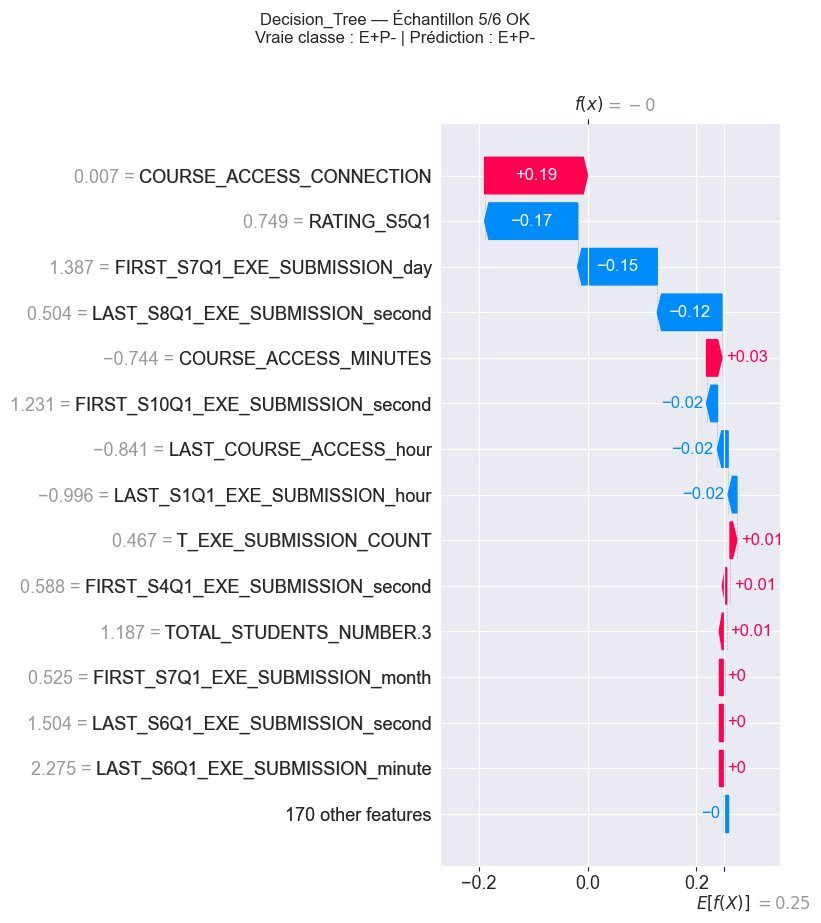

   Échantillon 5 : Vraie=E+P- | Prédit=E+P- OK


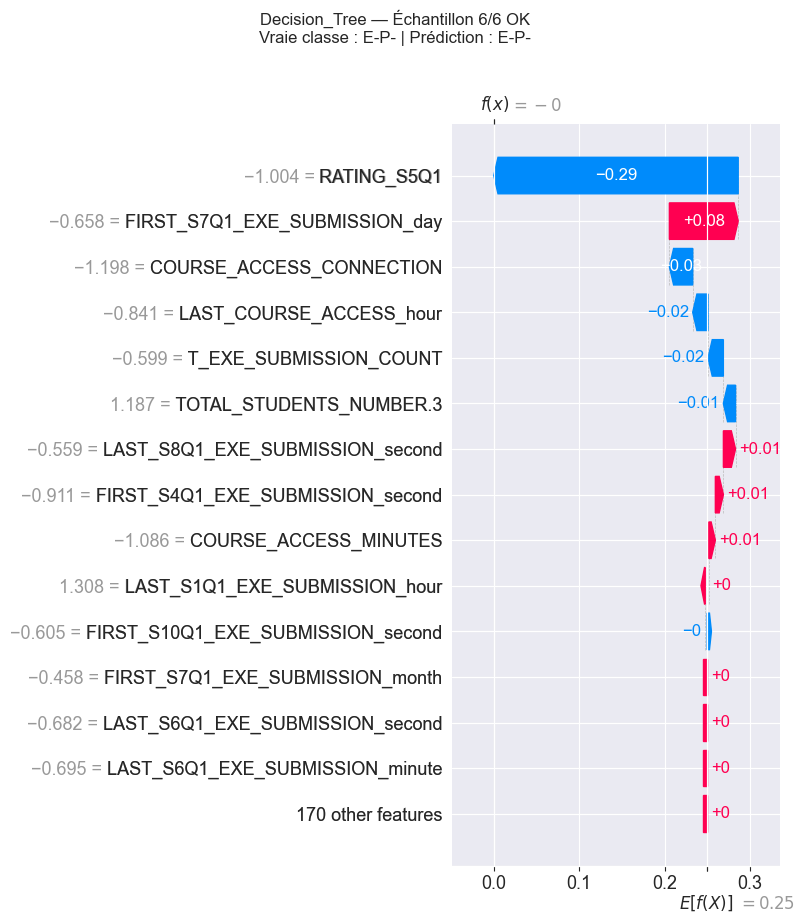

   Échantillon 6 : Vraie=E-P- | Prédit=E-P- OK

  GRAPHIQUES SHAP — Random_Forest

 Summary Plot...


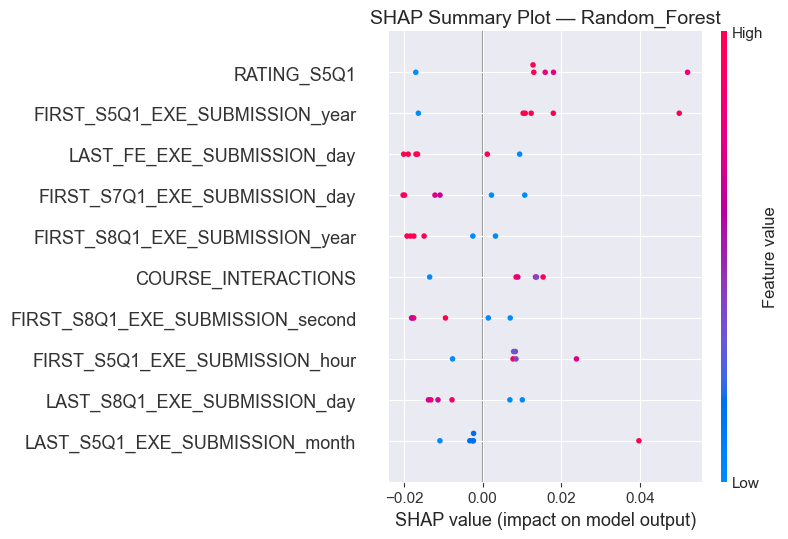


 Bar Plot...


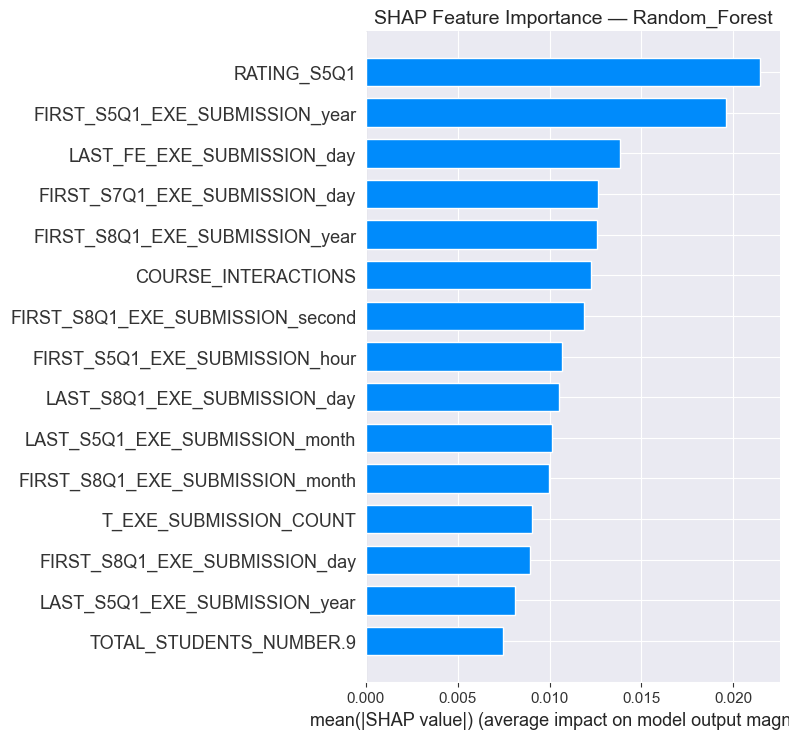


 Waterfall Plots (un par échantillon)...


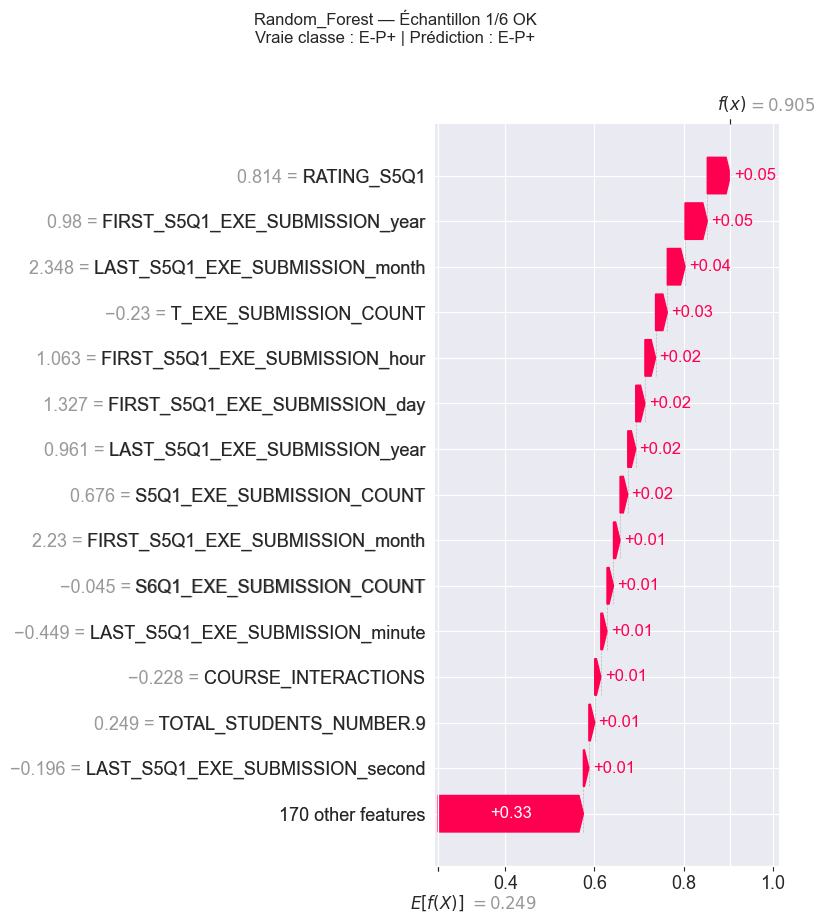

   Échantillon 1 : Vraie=E-P+ | Prédit=E-P+ OK


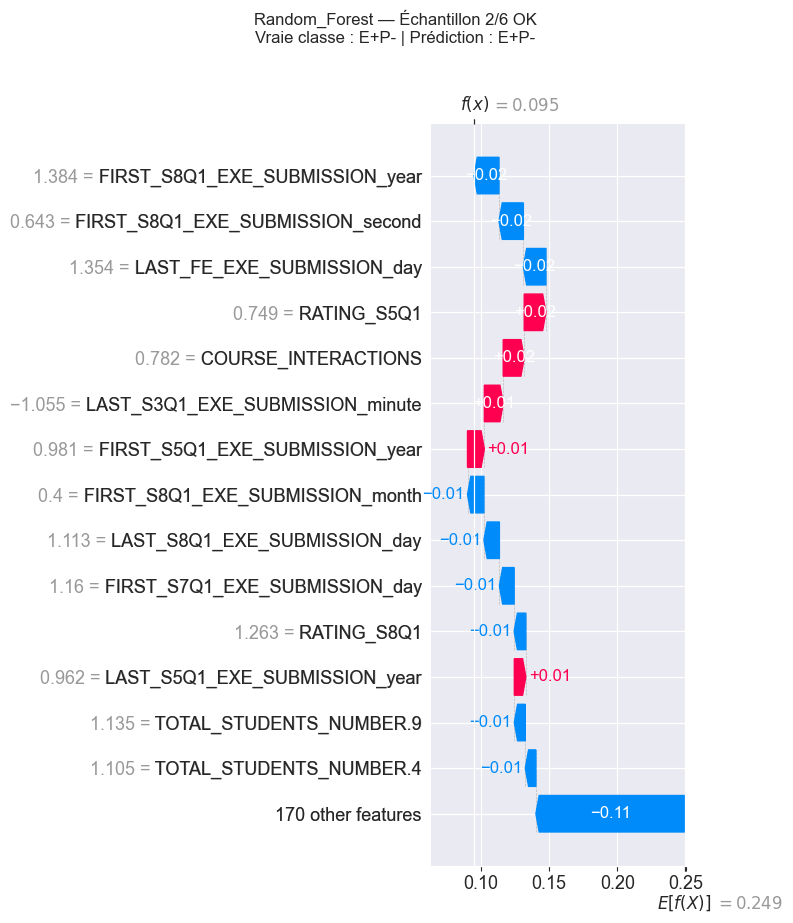

   Échantillon 2 : Vraie=E+P- | Prédit=E+P- OK


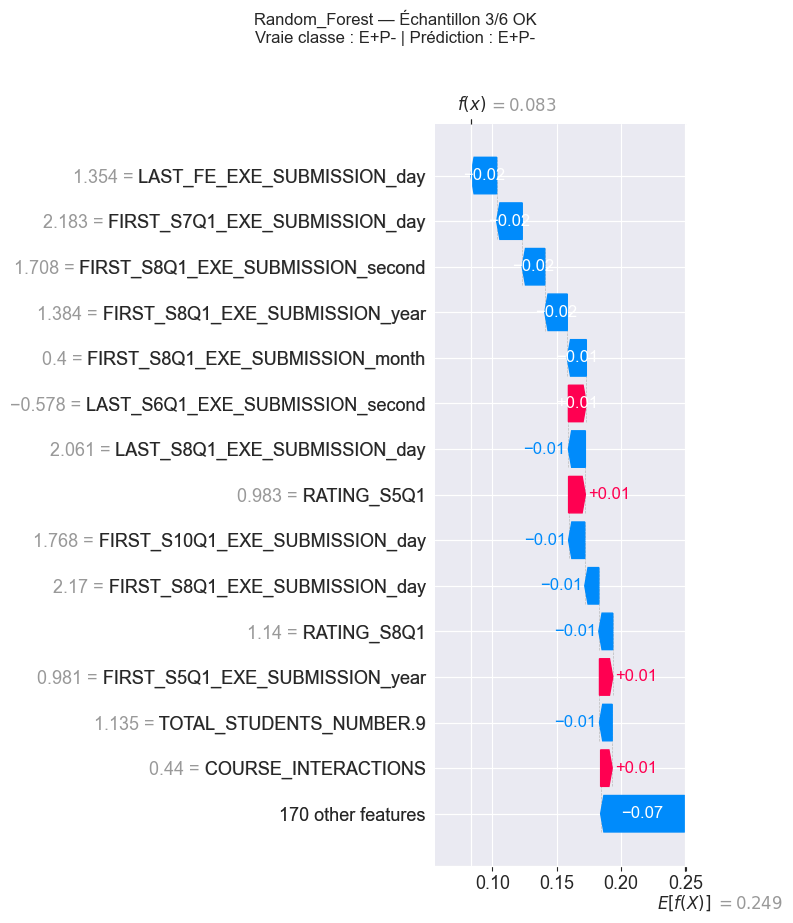

   Échantillon 3 : Vraie=E+P- | Prédit=E+P- OK


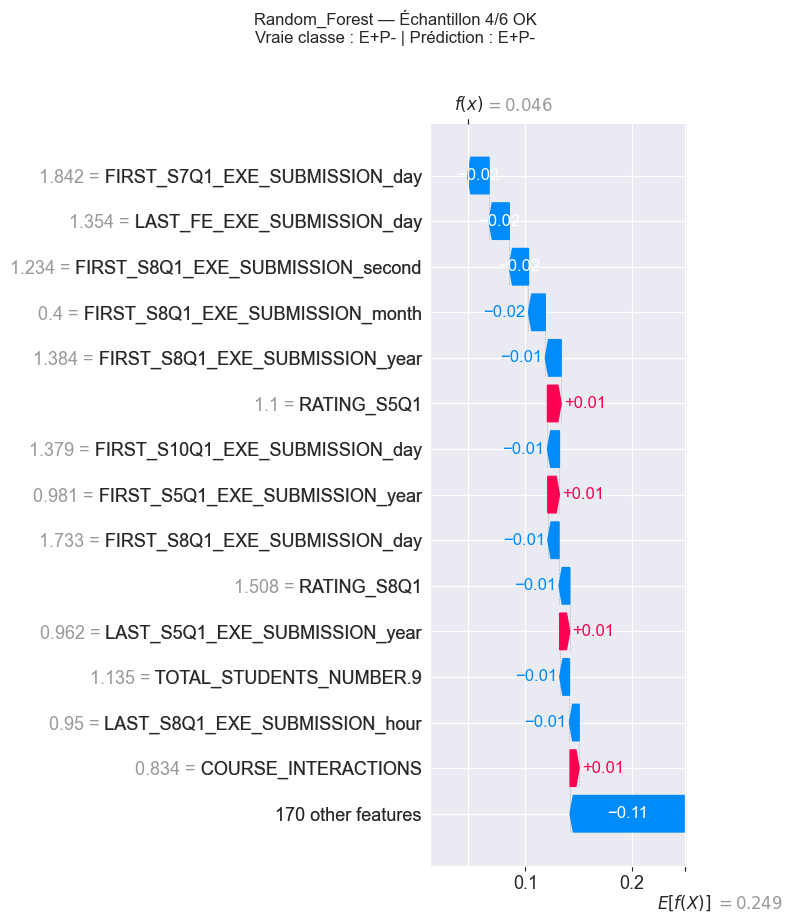

   Échantillon 4 : Vraie=E+P- | Prédit=E+P- OK


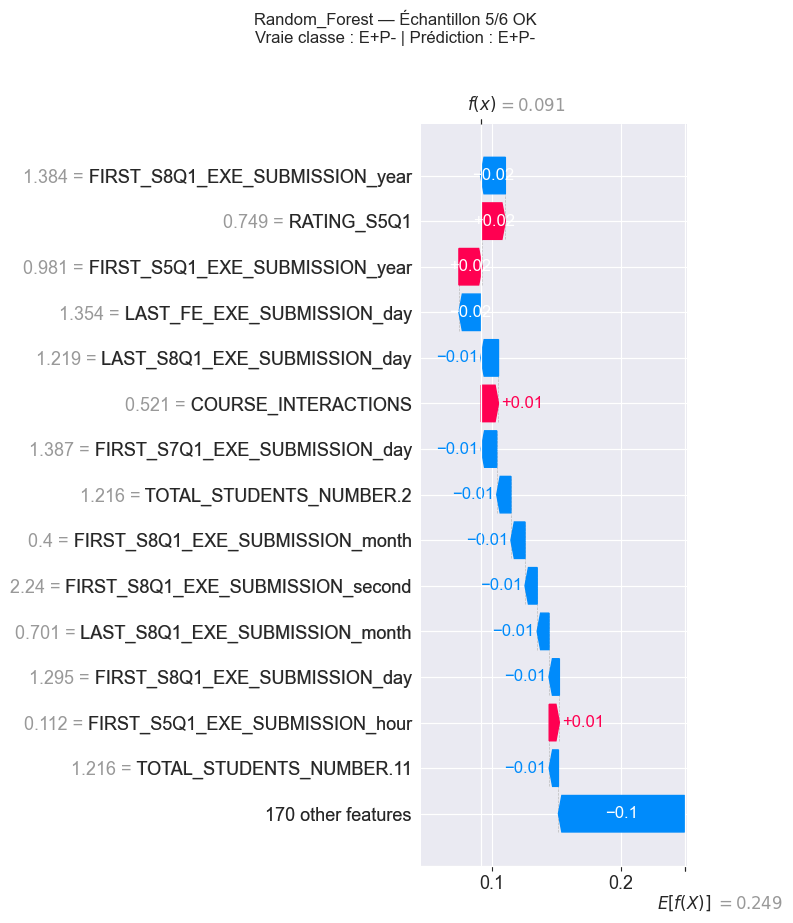

   Échantillon 5 : Vraie=E+P- | Prédit=E+P- OK


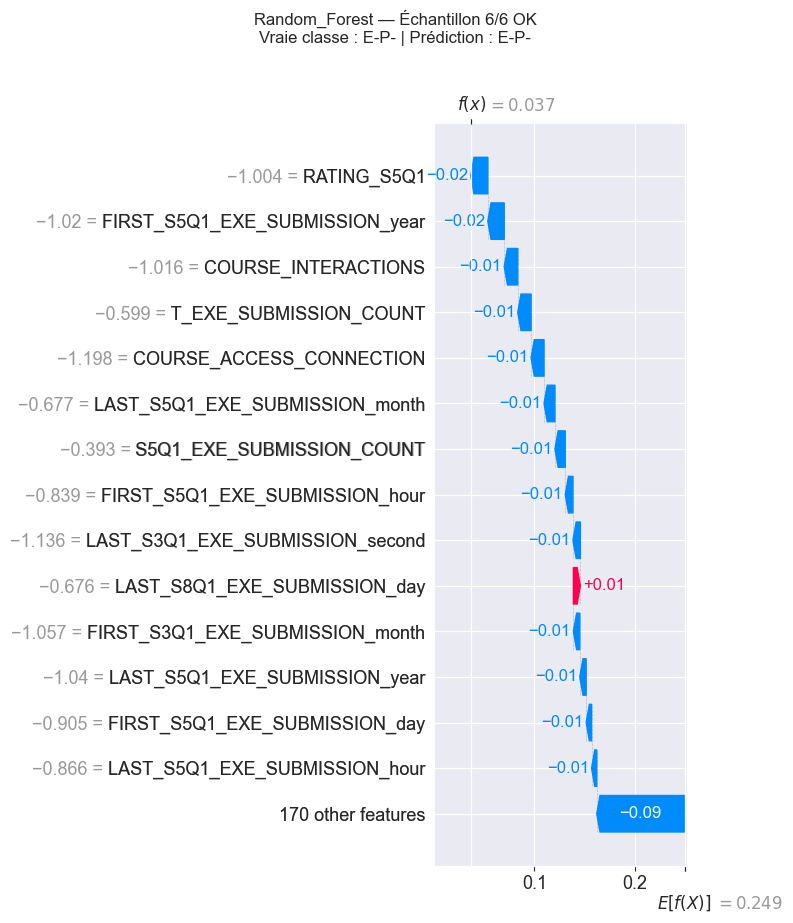

   Échantillon 6 : Vraie=E-P- | Prédit=E-P- OK

  GRAPHIQUES SHAP — XGBoost

 Summary Plot...


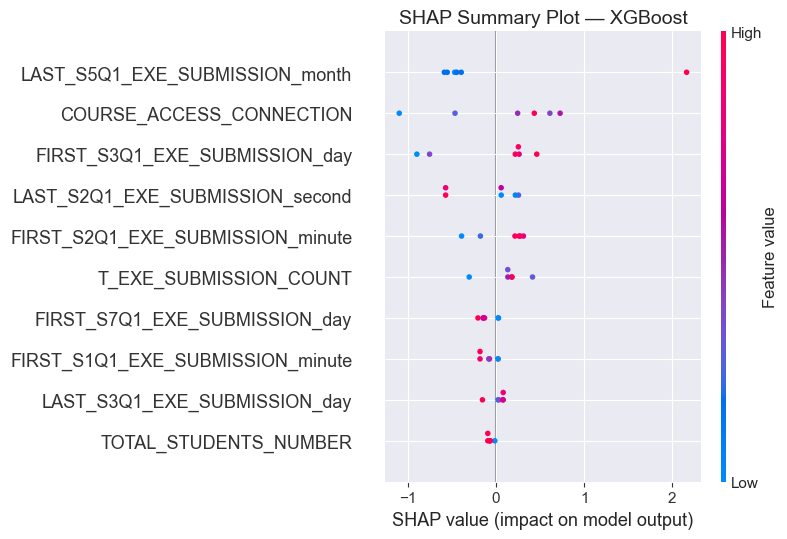


 Bar Plot...


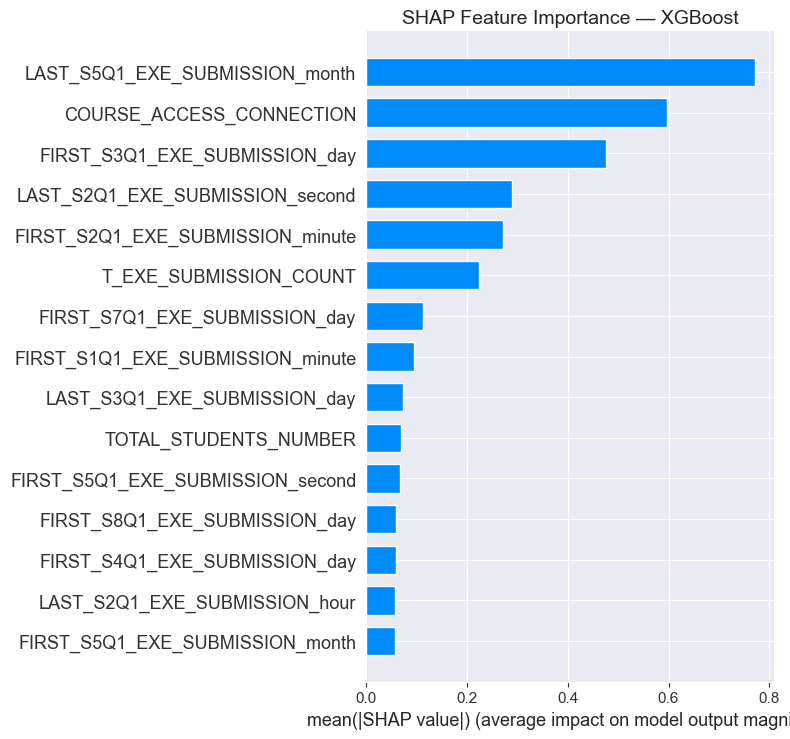


 Waterfall Plots (un par échantillon)...


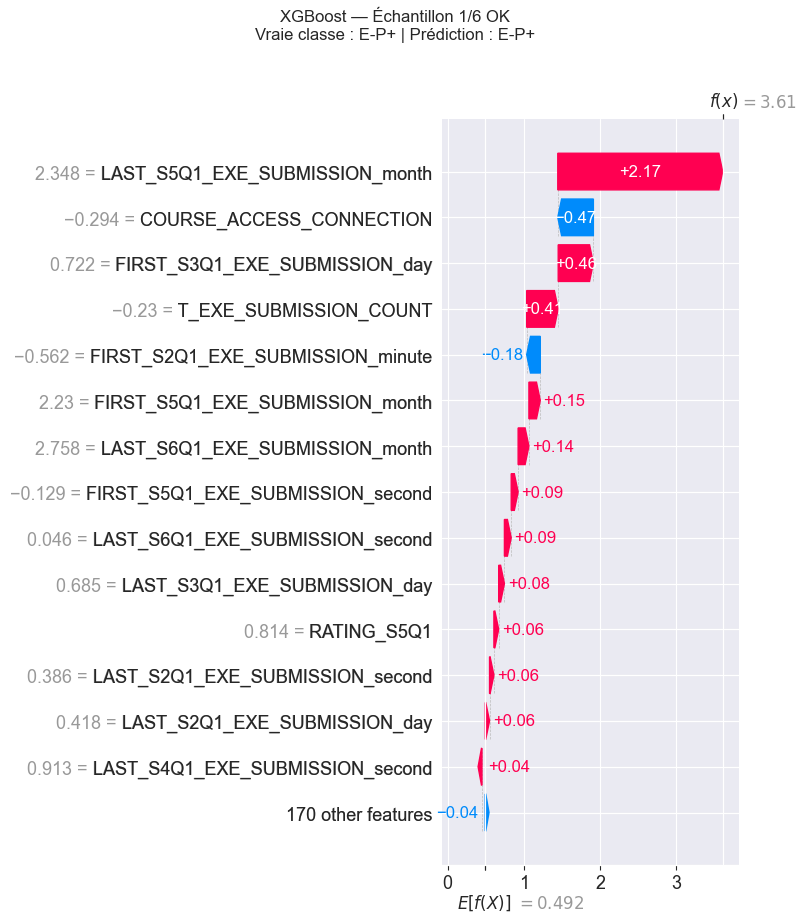

   Échantillon 1 : Vraie=E-P+ | Prédit=E-P+ OK


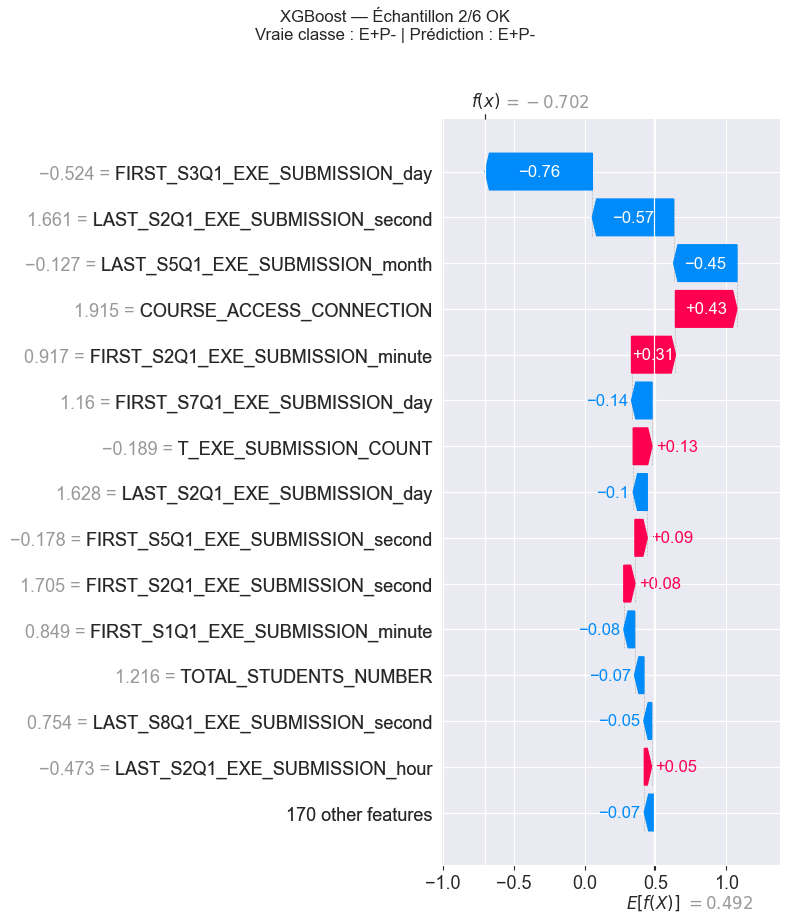

   Échantillon 2 : Vraie=E+P- | Prédit=E+P- OK


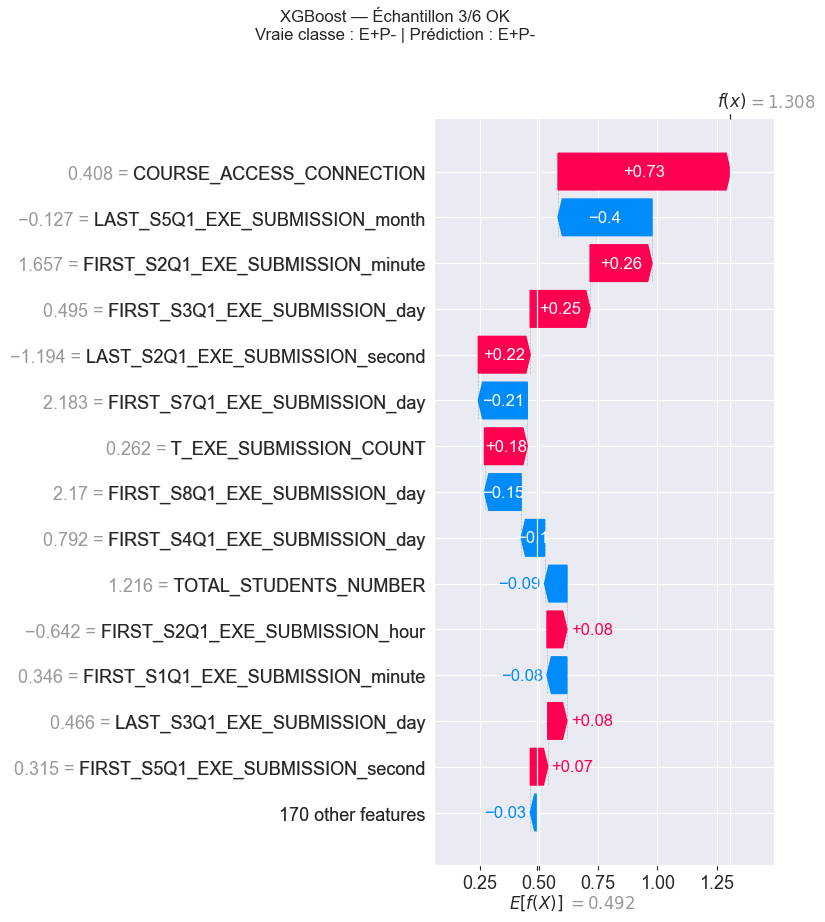

   Échantillon 3 : Vraie=E+P- | Prédit=E+P- OK


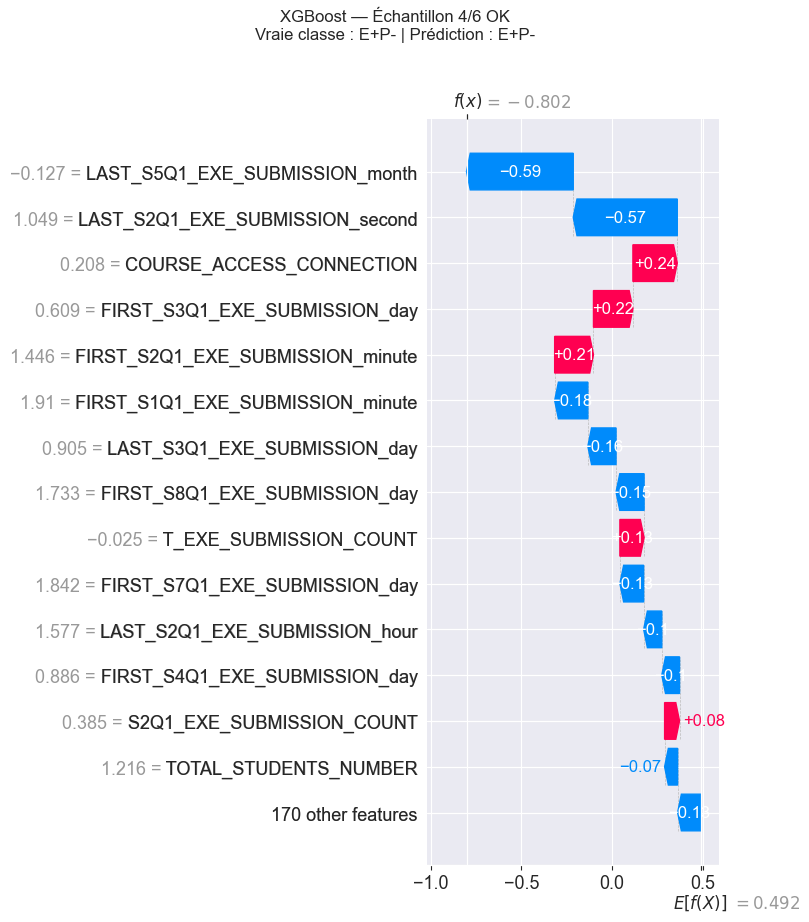

   Échantillon 4 : Vraie=E+P- | Prédit=E+P- OK


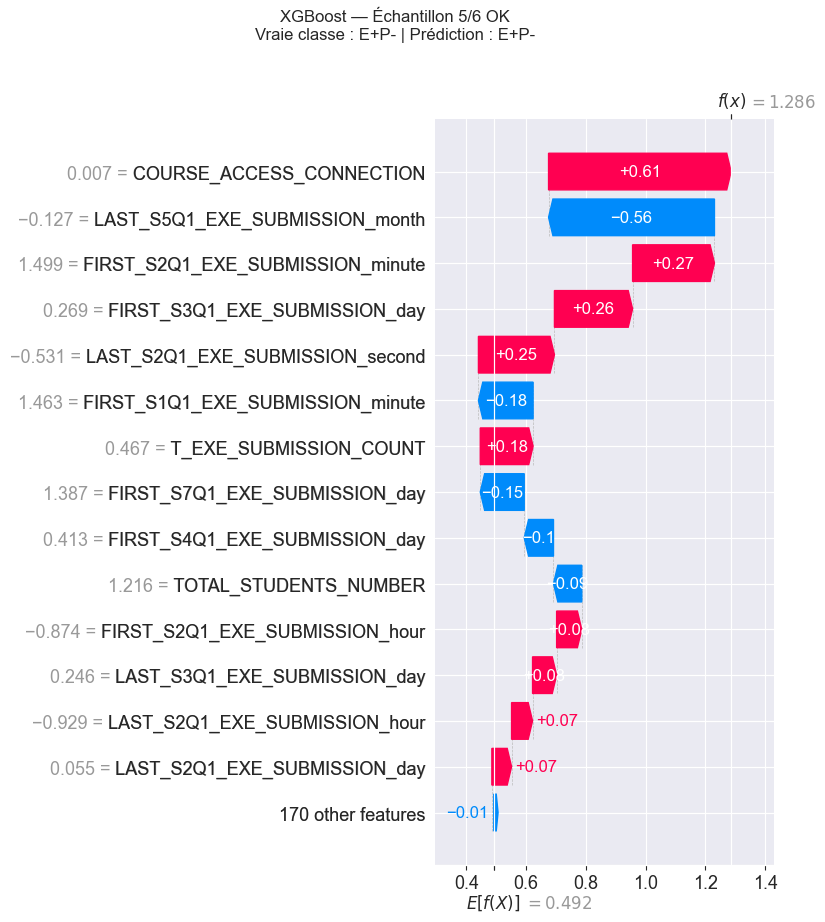

   Échantillon 5 : Vraie=E+P- | Prédit=E+P- OK


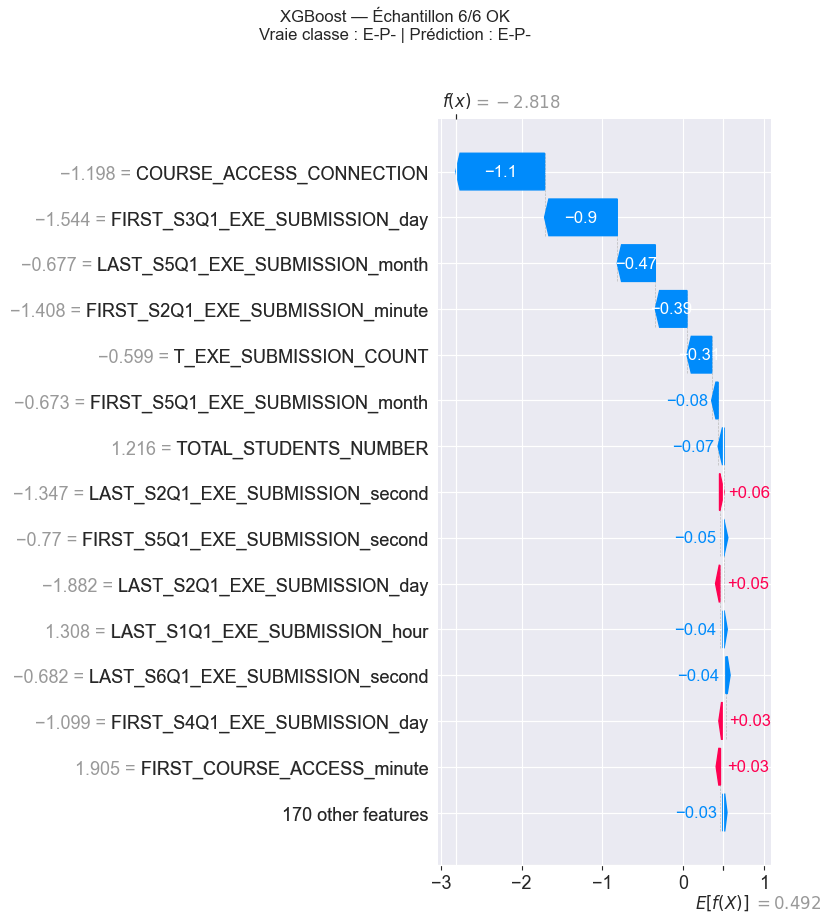

   Échantillon 6 : Vraie=E-P- | Prédit=E-P- OK

COMPARAISON SHAP ENTRE MODÈLES

  Heatmap de comparaison...


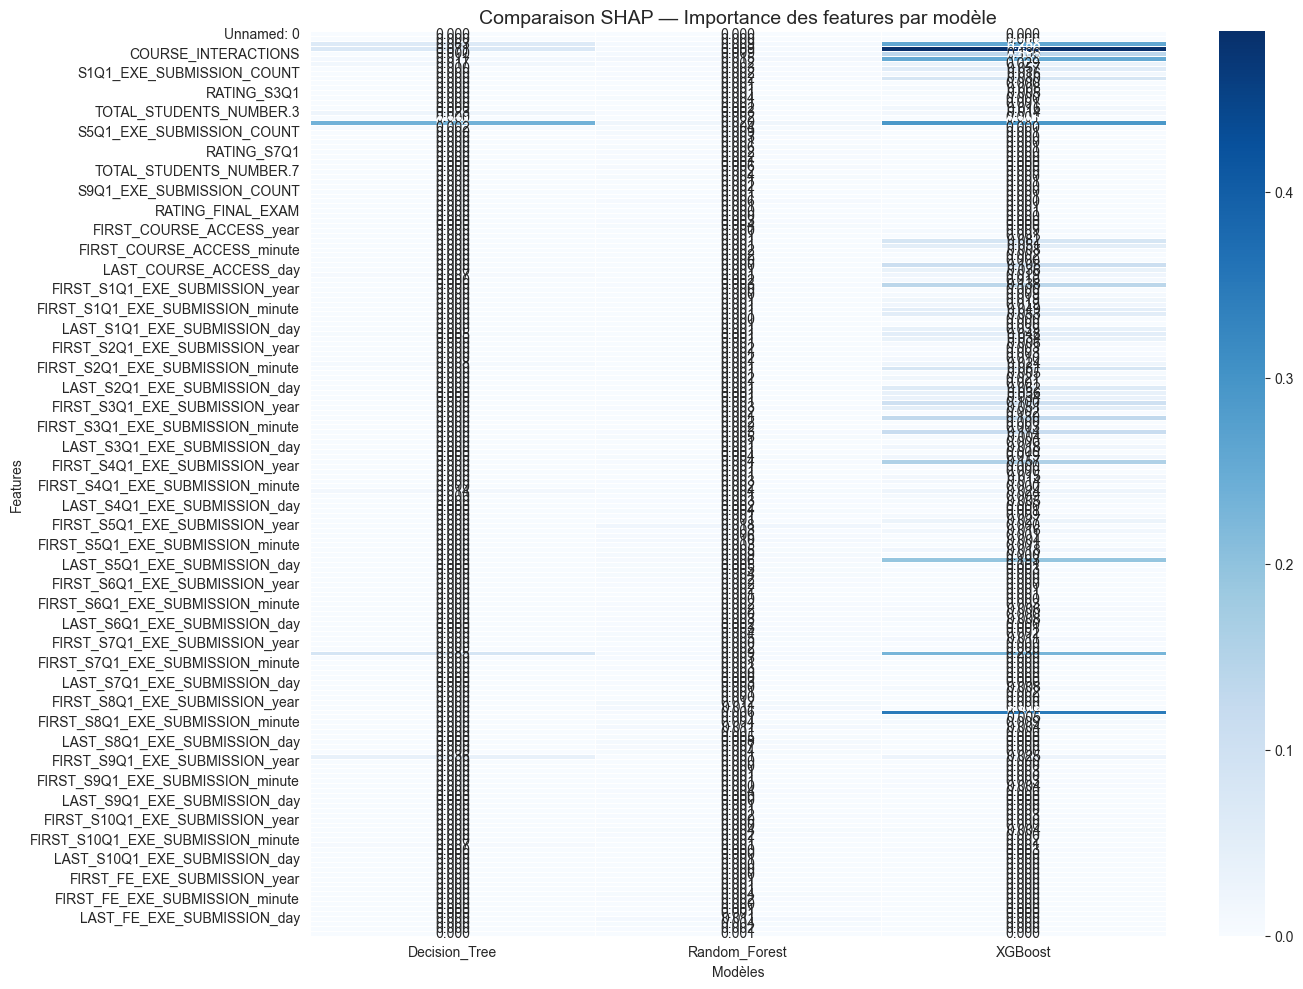


 Top 10 features (moyenne tous modèles)...


<Figure size 1400x600 with 0 Axes>

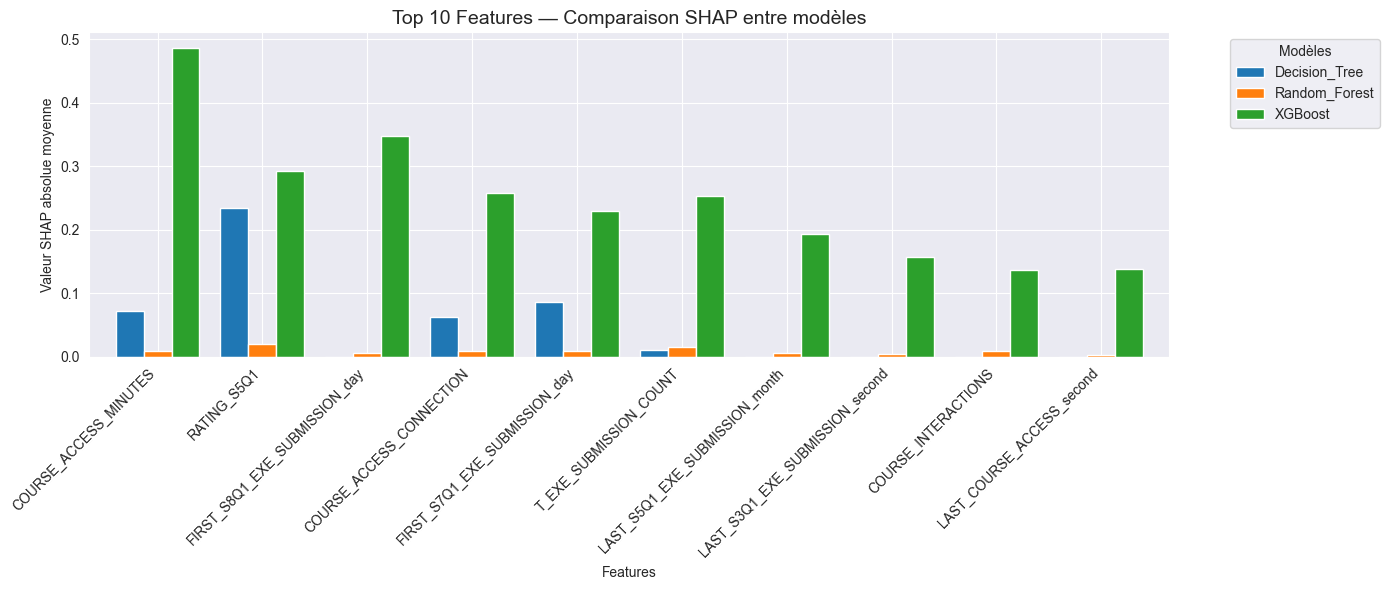


RÉSUMÉ — Top 5 features par modèle :

   Decision_Tree :
      RATING_S5Q1                              : 0.2339
      FIRST_S7Q1_EXE_SUBMISSION_day            : 0.0852
      COURSE_ACCESS_MINUTES                    : 0.0712
      COURSE_ACCESS_CONNECTION                 : 0.0627
      LAST_S8Q1_EXE_SUBMISSION_second          : 0.0364

   Random_Forest :
      RATING_S5Q1                              : 0.0201
      FIRST_S5Q1_EXE_SUBMISSION_year           : 0.0177
      T_EXE_SUBMISSION_COUNT                   : 0.0145
      FIRST_S8Q1_EXE_SUBMISSION_year           : 0.0122
      FIRST_S8Q1_EXE_SUBMISSION_month          : 0.0110

   XGBoost :
      COURSE_ACCESS_MINUTES                    : 0.4864
      FIRST_S8Q1_EXE_SUBMISSION_day            : 0.3476
      RATING_S5Q1                              : 0.2922
      COURSE_ACCESS_CONNECTION                 : 0.2578
      T_EXE_SUBMISSION_COUNT                   : 0.2521

 CALCUL DE LA STABILITÉ

   Modèle : SVM
   Création de l'explainer

100%|██████████| 1/1 [00:01<00:00,  1.60s/it]


      E-P+ : 0.8121 ± 0.0000


100%|██████████| 1/1 [00:01<00:00,  1.60s/it]


      E+P- : 0.4721 ± 0.0617


...

      E-P+ : 1.0000 ± 0.0000


100%|██████████| 1/1 [00:00<00:00,  8.69it/s]


      E+P- : 1.0000 ± 0.0000


100%|██████████| 1/1 [00:00<00:00,  8.73it/s]


      E-P- : 1.0000 ± 0.0000

   Modèle : XGBoost
   Création de l'explainer pour XGBoost...
TreeExplainer créé pour XGBoost
      E-P+ : 0.0000 ± 0.0000
      E+P- : 0.0000 ± 0.0000
      E-P- : 0.0000 ± 0.0000

Fidélité calculée

📊 RÉSUMÉ DES MÉTRIQUES SHAP

🤖 SVM
------------------------------------------------------------
 STABILITÉ (max = 1.0, plus c'est élevé mieux c'est) :
   E-P+     : 0.8121 ± 0.0000
   E+P-     : 0.4721 ± 0.0617
   E-P-     : 0.6314 ± 0.0000
   Overall  : 0.6385

🎯 FIDÉLITÉ (max = 1.0, plus c'est élevé mieux c'est) :
   E-P+     : 1.0000 ± 0.0000
   E+P-     : 1.0000 ± 0.0000
   E-P-     : 1.0000 ± 0.0000
   Overall  : 1.0000

 ÉVALUATION :
    Stabilité modérée — explications partiellement reproductibles
   Fidélité élevée — explications fidèles au modèle

🤖 LOGISTIC REGRESSION
------------------------------------------------------------
 STABILITÉ (max = 1.0, plus c'est élevé mieux c'est) :
   E-P+     : 1.0000 ± 0.0000
   E+P-     : 1.0000 ± 0.0000
   E-P-

In [8]:
shap_eval = SHAPEvaluator(evaluator)
shap_eval.run()